<a href="https://colab.research.google.com/github/itmesneha/Zero_to_Hero_Neural_Nets/blob/main/makemore_mlp_letsgooooo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
#build the vocab of characters & mappings to/from integers

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [8]:
# build the dataset

block_size = 3 # context length
X, Y = [], []
for w in words[:5]:
  print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [9]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [13]:
C = torch.randn((27, 2)) # embedding 27 characters into a 2d space

In [31]:
# X - This is your input data or index tensor.
# It contains integer indices, and its values must be in the range [0, 26]
# because of the size of C (27 rows).

emb = C[X] # basically C functions as a lookup table
# This is the output tensor or embedded data.
# It has the same first two dimensions as X, but gains the embedding dimension (2) from C.
emb.shape

torch.Size([32, 3, 2])

In [32]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [39]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
h

tensor([[ 0.1929,  0.7529,  0.9976,  ...,  1.0000,  0.9997,  0.9943],
        [-0.0651, -0.0207, -0.9910,  ...,  1.0000,  1.0000,  0.9532],
        [ 1.0000,  0.9995, -0.9671,  ...,  0.9658, -0.9969, -0.3661],
        ...,
        [-1.0000, -0.9998,  0.2581,  ...,  0.3629, -0.9549,  0.6552],
        [ 0.9632,  0.9634,  0.7260,  ...,  0.9567,  0.5338, -0.1081],
        [ 0.3603, -0.3267,  0.9234,  ...,  0.9141,  0.9524, -0.6059]])

In [40]:
h.shape

torch.Size([32, 100])

In [41]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [42]:
logits = h @ W2 + b2

In [43]:
logits.shape

torch.Size([32, 27])

In [44]:
counts = logits.exp()

In [45]:
prob = counts / counts.sum(1, keepdims = True)

In [46]:
prob.shape

torch.Size([32, 27])

In [48]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(18.4786)

In [49]:
# respectable now :)

In [106]:
# training split, dev/validation split, test split
# 80,10,10

def build_dataset(words):
  block_size = 3
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [130]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator = g)
W1 = torch.randn((30,200))
b1 = torch.randn(200)
W2 = torch.randn((200, 27))
b2 = torch.randn(27)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

In [131]:
sum(p.nelement() for p in parameters)

11897

In [132]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [133]:
lri = []
lossi = []
stepi = []

In [138]:
for i in range(50000):

  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2) --> overfitting a single batch
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])
  # print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  # lr = lrs[i]
  for p in parameters:
    p.data += -0.1 * p.grad
    # p.data += -lr * p.grad

  # track stats
  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

print(loss.item())

2.2282111644744873


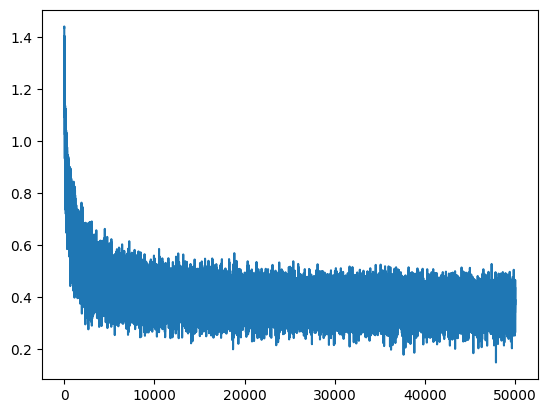

In [136]:
plt.plot(stepi, lossi)

In [137]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3975, grad_fn=<NllLossBackward0>)

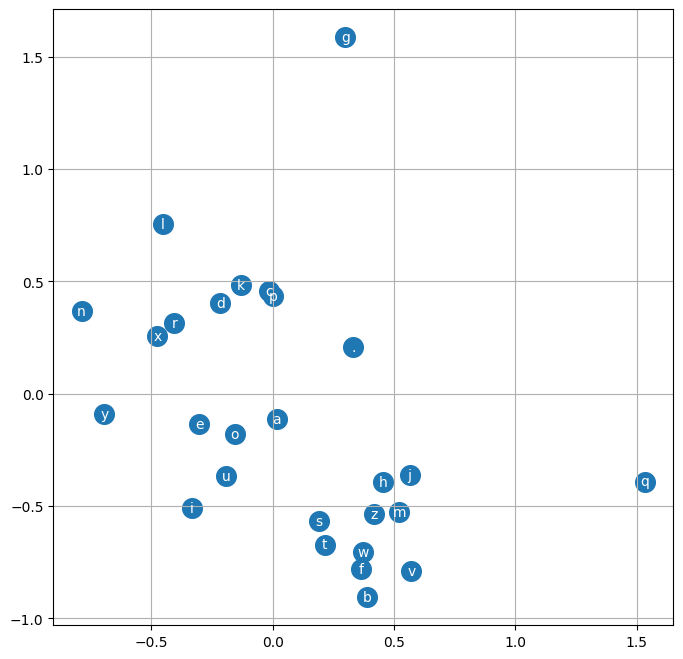

In [129]:
plt.figure(figsize=(8,8))
plt.scatter(C[:, 0].data, C[:,1].data, s = 200)
for i in range(C.shape[0]):
  plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha = 'center', va = 'center', color = 'white')
plt.grid('minor')

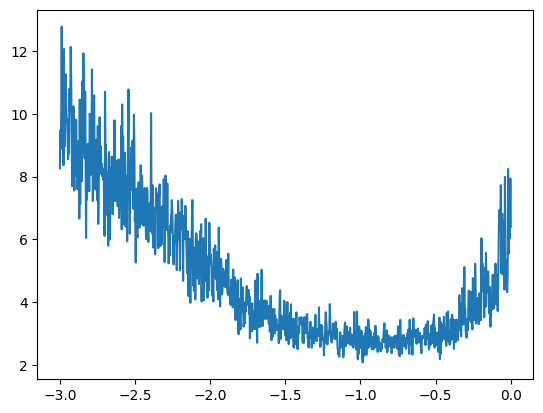

In [95]:
# plt.plot(lri, lossi)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])
